In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
'''On April 15, 1912, the Titanic sank after hitting an iceberg. Of 2,224 passengers and crew, only ~710 survived. 
    Our goal: understand which factors most influenced survival, and build analytical skills using real data.'''

891 - Training rows
12  - Columns
38% - Survived
3   - Missing cols


Key columns explained
Survived       --  0 = died, 1 = survived (our target variable)
Pclass         --  Ticket class: 1 = 1st (rich), 2 = 2nd, 3 = 3rd (poor)
SibSp / Parch  --  Number of siblings/spouses and parents/children aboard
Embarked       --  Port: C = Cherbourg, Q = Queenstown, S = Southampton


Questions we will answer
Did women survive at higher rates than men?
Did 1st class passengers have a survival advantage?
Did age influence survival (children first)?
Did where you boarded the ship matter?

In [3]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
# rows
len(df)

891

In [10]:
#missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
#To find directly in one line

print(df.isnull().sum().idxmax())
print(df.isnull().sum().max())

Cabin
687


In [12]:
#missing percentage

missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct.round(2))

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [13]:
#how manu survived vs died?

df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
df['Survived'].value_counts(normalize = True).round(3) * 100

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

In [ ]:
###################################################### Data Cleaning ########################################################

                            '''Real data is always messy. Cleaning is 60–70% of a data analyst's work.
                            We handle missing values, drop useless columns, and create new features.'''

In [64]:
# Just for reference — missing values before cleaning
reference = pd.DataFrame({
    'Column'        : ['Age',  'Cabin', 'Embarked'],
    'Missing Count' : [177,    687,     2],
    'Missing %'     : [19.9,   77.1,    0.2],
    'Action'        : ['Fill with median', 
                       'Drop column', 
                       'Fill with mode']
})
print(reference)

     Column  Missing Count  Missing %            Action
0       Age            177       19.9  Fill with median
1     Cabin            687       77.1       Drop column
2  Embarked              2        0.2    Fill with mode


In [66]:
# check missing values

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count' : missing, 'Missing %' : missing_pct.round(2)})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


In [ ]:
#Handle missing values

In [65]:
# AGE: Fill missing with median (more robust than mean)
# Check median first
print(df['Age'].median())

# Fill missing
df['Age'] = df['Age'].fillna(df['Age'].median())

28.0


In [62]:
# WHY MEDIAN? Because outliers (very old passengers) 
# skew the mean. Median is more representative.

print(f"Age Mean : {df['Age'].mean():.1f}" )
print(f"Age Median : {df['Age'].median():.2f}")

Age Mean : 29.4
Age Median : 28.00


In [ ]:
'''Mean   = average value
Median = middle value
Mode   = most frequently occurring value''''

In [47]:
# EMBARKED: Fill 2 missing with mode (most common value)
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [67]:
df['Embarked'] = df['Embarked'].fillna('S')
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14848\2147982860.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [68]:
print(df['Embarked'].isnull().sum())

0


In [ ]:
# CABIN: 77% missing → too much to impute, just drop it
df.drop(columns = ['Cabin'])

In [ ]:
# Also drop columns not useful for analysis
df.drop(columns=['PassengerId', 'Ticket', 'Name'])

In [52]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')

In [60]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
#Feature engineering

In [ ]:
'''Key insight: FamilySize helps us understand if traveling with family improved survival odds — 
people alone might have had nobody to help them find lifeboats.'''

In [22]:
df['Family Size'] = df['SibSp'] + df['Parch'] + 1
df['Is Alone'] = (df['Family Size'] == 1 ).astype(int)
df['Age Group'] = pd.cut(df['Age'], bins = [0,12,17,35,60,100], labels = ['Child','Teen','Adult','Middle-aged','Senior'])
df['Sex_Num'] = (df['Sex'] == 'female').astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Is Alone,Age Group,Sex_Num
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Adult,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Middle-aged,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Adult,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Adult,0


In [23]:
#Problems - Practice

In [24]:
#Try filling Age with mean instead of median — does it change much?
print(f"Age Mean: {df['Age'].mean():.1f}")
print(f"Age Median: {df['Age'].median():.2f}")

Age Mean: 29.7
Age Median: 28.00


In [25]:
#Create a 'FareGroup' column with pd.qcut() dividing Fare into 4 quartiles
df['FareGroup'] = pd.qcut(df['Fare'], q = 4, labels = ['Low','Medium','High','Very High'])
df['FareGroup'].value_counts()
df[['Fare','FareGroup']].head(10)

,Fare,FareGroup
0,7.2500,Low
1,71.2833,Very High
2,7.9250,Medium
3,53.1000,Very High
4,8.0500,Medium
5,8.4583,Medium
6,51.8625,Very High
7,21.0750,High
8,11.1333,Medium
9,30.0708,High


In [26]:
#check survival by FareGroup:
print(df.groupby('FareGroup')['Survived'].mean().round(2) * 100)

FareGroup
Low          20.0
Medium       30.0
High         45.0
Very High    58.0
Name: Survived, dtype: float64


In [27]:
#Use df.duplicated().sum() — are there duplicate rows?
df = df.drop_duplicates()
df = df.reset_index(drop = True)
print('New Shape : ', df.shape)
print('Duplicates Left : ', df.duplicated().sum())

New Shape :  (891, 17)
Duplicates Left :  0


In [28]:
##########################################################  EDA #######################################################################################
     '''Exploratory Data Analysis (EDA) is an important step in data analysis where we explore, summarize, and visualize data to understand its 
                             structure, detect patterns, identify anomalies, test assumptions, 
                and check relationships between variables before applying any machine learning or statistical models.'''

IndentationError: unexpected indent (3508418058.py, line 2)

In [29]:
# Survival by gender (most powerful predictor)

survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print(survival_by_sex.round(1))

Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [30]:
#Survival by passenger class

Survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100
print(Survival_by_pclass.round(1))

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [31]:
#Cross-tabulation: Sex × Pclass

# The most powerful combo — class AND gender
pivot = df.pivot_table(values = 'Survived', index = 'Pclass', columns = 'Sex', aggfunc = 'mean').round(3) * 100
print(pivot)

Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5


In [32]:
# Survival rate of Children only:

# Filter only children (age below 12)

children = df[df['Age'] > 12]

print(f'Total Children : {len(children)}')
print(f'Children Survival Rate : {children['Survived'].mean() * 100:.1f}%')

Total Children : 645
Children Survival Rate : 38.8%


In [33]:
children_by_pclass = children.groupby('Pclass')['Survived'].mean() * 100
print(children_by_pclass.round(2))

Pclass
1    65.38
2    42.31
3    21.17
Name: Survived, dtype: float64


In [43]:
# Age distribution analysis

# Stats comparison: survivors vs non-survivors
print(df.groupby('Survived')['Age'].describe().round(2))

# Correlation matrix — which features relate to Survived?
corr = df[['Survived', 'Pclass', 'Age', 'Fare',
           'Sex_Num', 'Family Size','Is Alone']].corr()
print(corr['Survived'].sort_values(ascending = False).round(2))

          count   mean    std   min   25%   50%   75%   max
Survived                                                   
0         424.0  30.63  14.17  1.00  21.0  28.0  39.0  74.0
1         290.0  28.34  14.95  0.42  19.0  28.0  36.0  80.0
Survived       1.00
Sex_Num        0.54
Fare           0.26
Family Size    0.02
Age           -0.08
Is Alone      -0.20
Pclass        -0.34
Name: Survived, dtype: float64


In [ ]:
                                            #=============================================#
                                            #         CORRELATION MATRIX                  #
                                            #=============================================#

# Correlation = how strongly two columns
# are related to each other
# Range is always between -1 and +1

# SIGN meaning:
# + sign → both go UP together (same direction)
# - sign → one UP, other DOWN (opposite direction)

# NUMBER meaning:
# closer to 1.0 → STRONGLY related (important!)
# closer to 0.0 → WEAKLY related (not important!)

# IMPORTANT RULE:
# Sign (+/-) tells DIRECTION
# Number tells IMPORTANCE
# -0.34 is MORE important than +0.02 ✅

corr = df[['Survived', 'Pclass', 'Age', 'Fare',
           'Sex_Num', 'Family Size', 'Is Alone']].corr()

print(corr['Survived'].sort_values(ascending=False).round(2))

# OUTPUT:
# Survived      1.00  → always 1 with itself
# Sex_Num       0.54  → STRONGEST! female survived more
# Fare          0.26  → higher fare = better survival
# Family Size   0.02  → almost no relation (weakest!)
# Age          -0.08  → older = slightly less survival
# Is Alone     -0.20  → alone = worse survival
# Pclass       -0.34  → higher class number = worse survival

# RANKING BY IMPORTANCE (ignore +/- sign):
# Rank 1 → Sex_Num      0.54  most important!
# Rank 2 → Pclass      -0.34  very important!
# Rank 3 → Fare         0.26  important
# Rank 4 → Is Alone    -0.20  moderate
# Rank 5 → Age         -0.08  weak
# Rank 6 → Family Size  0.02  not important!

# To see importance without +/- sign:
corr['Survived'].abs().sort_values(ascending=False).round(2)
# abs() removes the sign → shows pure importance

# PCLASS IS NEGATIVE BECAUSE:
# Pclass 1 → 63% survival ✅ (rich)
# Pclass 2 → 47% survival
# Pclass 3 → 24% survival ❌ (poor)
# Number goes UP   1→2→3
# Survival goes DOWN 63→47→24
# UP + DOWN = NEGATIVE correlation!

# IS ALONE IS NEGATIVE BECAUSE:
# Is Alone = 1 means traveling alone
# Alone passengers survived LESS
# So when IsAlone goes UP
# Survival goes DOWN = NEGATIVE ✅

# KEY INSIGHT:
# Gender matters MOST  → 0.54
# Class matters SECOND → 0.34
# Age barely matters   → 0.08
# "Women and Children First" rule
# + Class location on ship
# determined who lived and died!

In [52]:
#Did age influence survival (children first)?

# Check correlation of age with survival
print(df['Age'].corr(df['Survived']))       # Age alone barely matters!

-0.07722109457217763


In [53]:
#Check children survival rate:

# Define children as age below 12
children = df[df['Age'] < 12]
adults   = df[df['Age'] >= 12]

print(f"Children survival: {children['Survived'].mean()*100:.1f}%")
print(f"Adults survival:   {adults['Survived'].mean()*100:.1f}%")
print(f"Overall survival:  {df['Survived'].mean()*100:.1f}%")

Children survival: 57.4%
Adults survival:   38.9%
Overall survival:  38.4%


In [65]:
#Did where you boarded the ship matter?
#Find survival rate by Embarked port — does it differ significantly?

survival_by_port = df.groupby('Embarked')['Survived'].mean() * 100
print(survival_by_port.round(2))

Embarked
C    55.36
Q    38.96
S    33.70
Name: Survived, dtype: float64


In [88]:
                                                                # practice - problems

#Run groupby on 'AgeGroup' to find survival by age group

AgeGroup_by_survival = df.groupby('Age Group')['Survived'].mean() * 100
print(AgeGroup_by_survival.round(2))

Age Group
Child          57.97
Teen           47.73
Adult          38.02
Middle-aged    40.00
Senior         22.73
Name: Survived, dtype: float64


In [66]:
df['Family Size'].value_counts()

Family Size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [ ]:
Family Size   Count
1             537   ← 537 passengers traveled ALONE
2             161   ← you + 1 family member
3             102   ← you + 2 family members
4              29   ← you + 3 family members
5              15   ← you + 4 family members
6              22   ← you + 5 family members
7              12   ← you + 6 family members
8               6   ← you + 7 family members
11              7   ← you + 10 family members!

In [ ]:
########################################################## Summary Of EDA #############################################################################
# The Ultimate finding:
Best chance of survival:
→ Female ✅
→ 1st class ✅
→ Boarded at Cherbourg ✅
→ Traveling with family ✅
→ Young age ✅

Result: 96.8% survival! ✅✅✅

Worst chance of survival:
→ Male ❌
→ 3rd class ❌
→ Boarded at Southampton ❌
→ Traveling alone ❌
→ Old age ❌

Result: 13.5% survival ❌❌❌


# One line summary
Gender and Class were DIRECT factors ✅
Port was INDIRECT factor
(just reflected who was rich or poor)

Everything ultimately came down to:
WHO YOU WERE + WHERE YOU SAT
ON THE SHIP! 🚢

In [ ]:
################################################################ Visualizations #######################################################################

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look professional
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [68]:
#Plot 1 — Overall Survival Count

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3688\699482691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived',


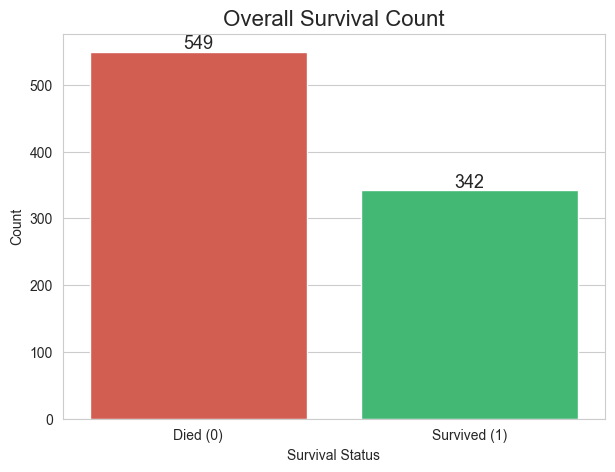

In [70]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Survived',
              palette=['#e74c3c', '#2ecc71'])

# Add labels on bars
plt.title('Overall Survival Count', fontsize=16)
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'])
plt.xlabel('Survival Status')
plt.ylabel('Count')

# Add count on top of each bar
for i, v in enumerate([549, 342]):
    plt.text(i, v + 5, str(v),
             ha='center', fontsize=13)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3688\1249546628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived',


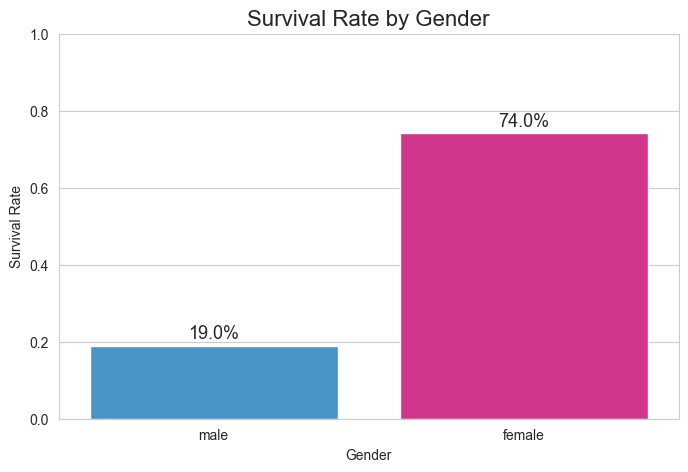

In [73]:
#Plot 2 — Survival by Gender

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Sex', y='Survived',
            palette=['#3498db', '#e91e8c'],errorbar=None)

plt.title('Survival Rate by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

# Add percentage on top of bars
for i, v in enumerate([0.19, 0.74]):
    plt.text(i, v + 0.02, f'{v*100:.1f}%',
             ha='center', fontsize=13)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3688\4083330082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived',


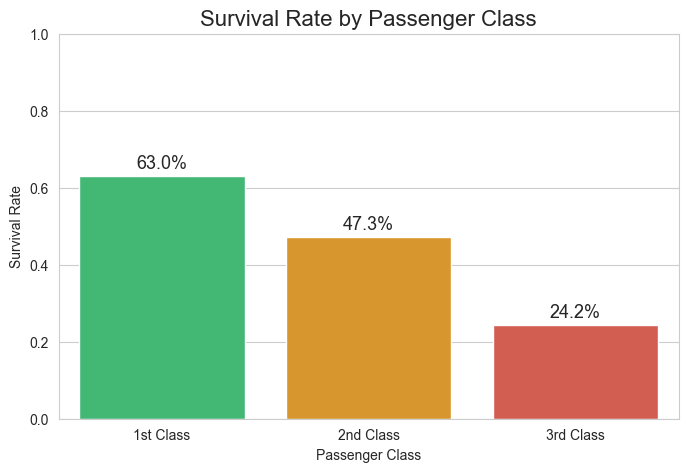

In [75]:
# Plot 3 - Survival by Class

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived',
            palette=['#2ecc71', '#f39c12', '#e74c3c'], errorbar = None)

plt.title('Survival Rate by Passenger Class', fontsize=16)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])

# Add percentage on top of bars
for i, cls in enumerate([1, 2, 3]):
    v = df[df['Pclass']==cls]['Survived'].mean()
    plt.text(i, v + 0.02, f'{v*100:.1f}%',
             ha='center', fontsize=13)

plt.show()

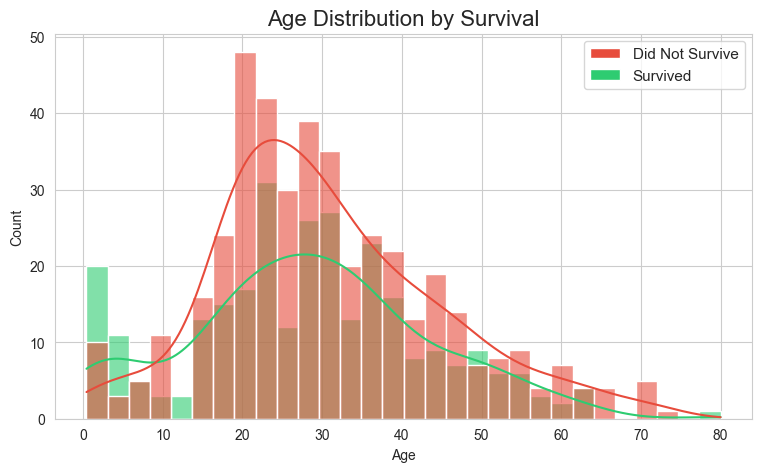

In [76]:
#Plot 4 - Age Distribution

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             palette={0: '#e74c3c', 1: '#2ecc71'},
             kde=True, alpha=0.6, edgecolor='white')

plt.title('Age Distribution by Survival', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Count')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Did Not Survive'),
                   Patch(facecolor='#2ecc71', label='Survived')]
plt.legend(handles=legend_elements, fontsize=11)

plt.show()

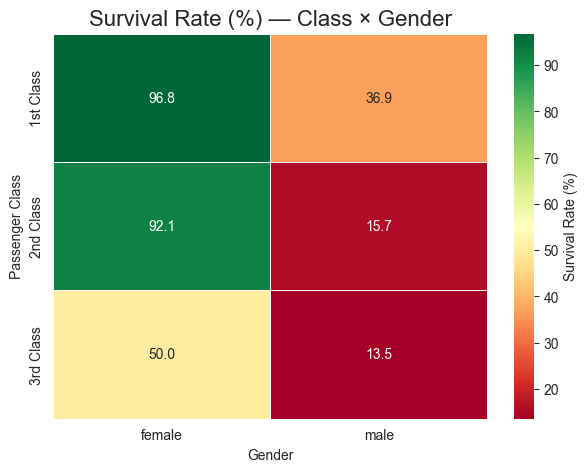

In [77]:
#Plot 5 - Heatmap Class x Gender

pivot = df.pivot_table(values='Survived', index='Pclass',
                       columns='Sex', aggfunc='mean') * 100
pivot.index = ['1st Class', '2nd Class', '3rd Class']

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Survival Rate (%)'})

plt.title('Survival Rate (%) — Class × Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Passenger Class')

plt.show()

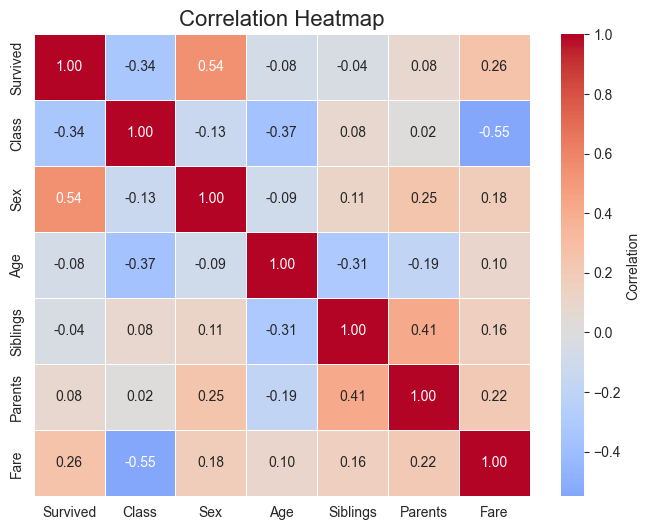

In [78]:
#Plot 6 - Correlation Heatmap

df['Sex_num'] = df['Sex'].map({'male': 0, 'female': 1})
cols = ['Survived', 'Pclass', 'Sex_num', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[cols].corr()
corr.columns = corr.index = ['Survived', 'Class', 'Sex',
                              'Age', 'Siblings', 'Parents', 'Fare']

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlation'})

plt.title('Correlation Heatmap', fontsize=16)

plt.show()

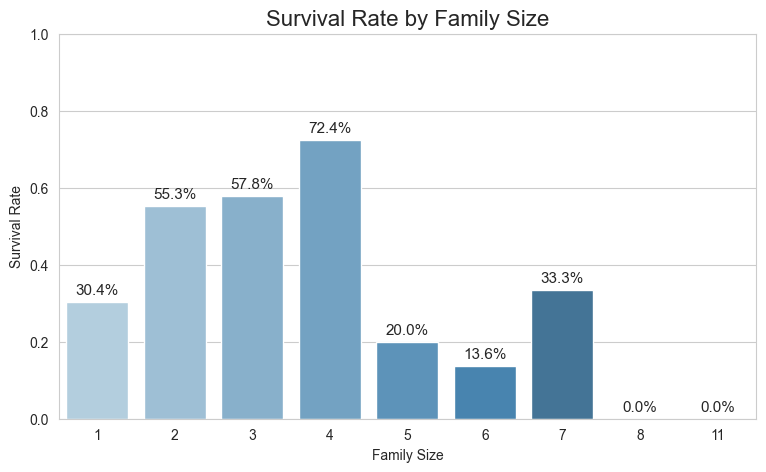

In [79]:
#Plot 7 - Family Size vs Survival

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='FamilySize', y='Survived',
            hue='FamilySize', legend=False,
            palette='Blues_d',
            errorbar=None)

plt.title('Survival Rate by Family Size', fontsize=16)
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

survival_rates = df.groupby('FamilySize')['Survived'].mean()
for i, (fam, v) in enumerate(survival_rates.items()):
    plt.text(i, v + 0.02, f'{v*100:.1f}%',
             ha='center', fontsize=11)

plt.show()

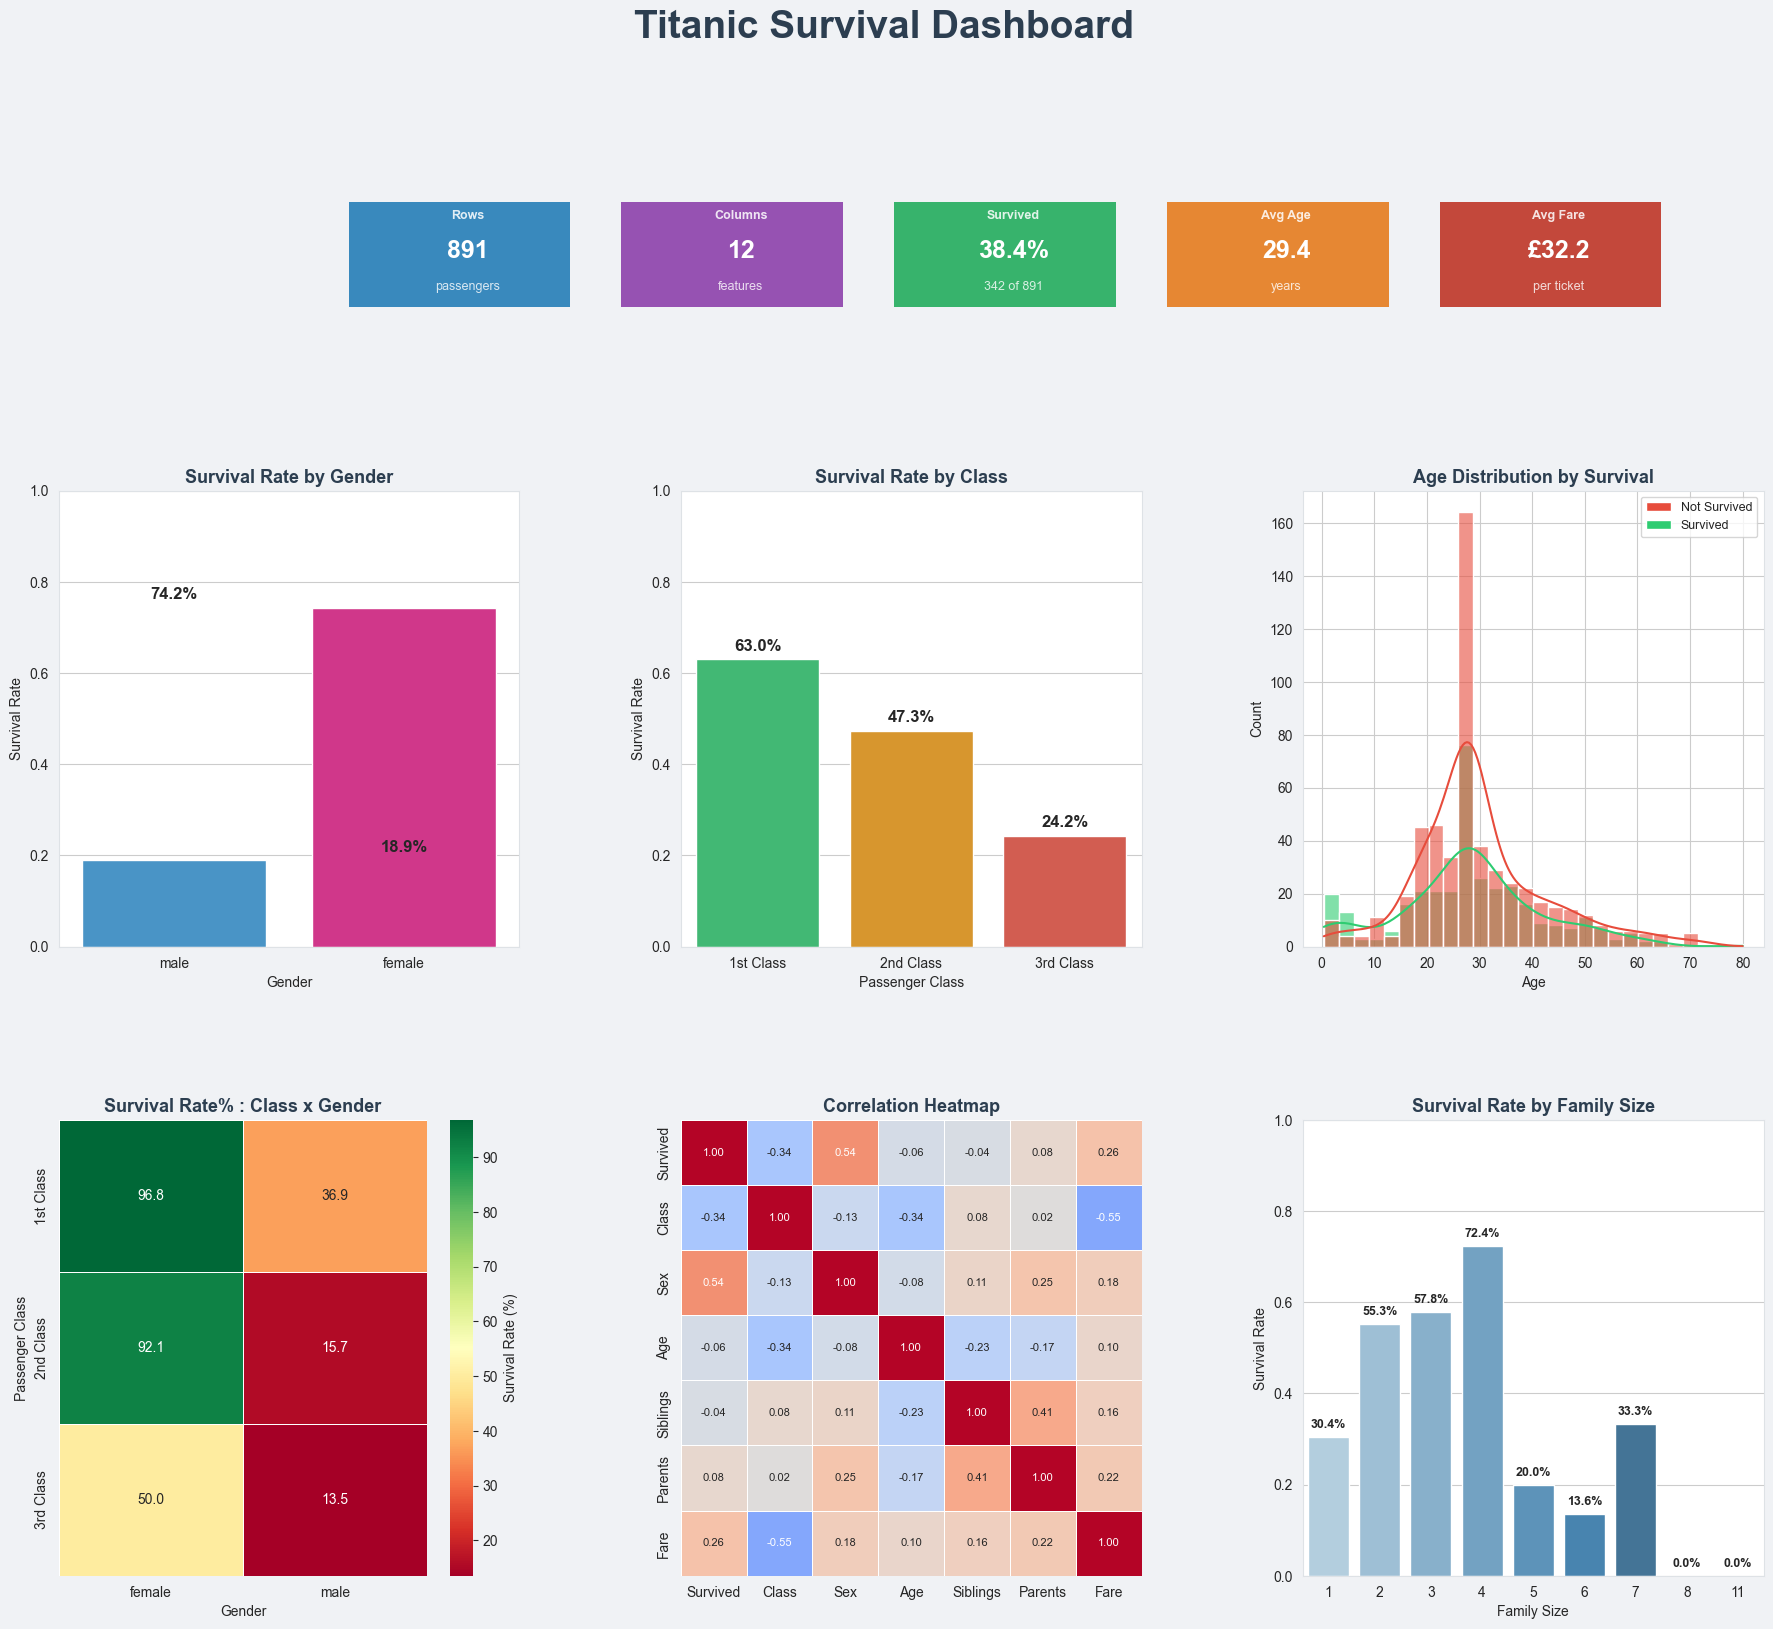

Dashboard saved as titanic_dashboard.png


In [87]:
################################################################### DASHBOARD #########################################################################
# fillna
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Fare']       = df['Fare'].fillna(df['Fare'].median())
df['Sex_num']    = df['Sex'].map({'male': 0, 'female': 1})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# ── Metrics ────────────────────────────────────────────────────
total_rows     = len(df)
total_cols     = 12
survived_count = df['Survived'].sum()
survived_pct   = df['Survived'].mean() * 100
avg_age        = df['Age'].mean()
avg_fare       = df['Fare'].mean()

# ── Figure Setup ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#f0f2f5')

fig.suptitle('Titanic Survival Dashboard',
             fontsize=28, fontweight='bold', y=0.98, color='#2c3e50')

# GridSpec: row 0 = metrics, rows 1-2 = plots
gs = gridspec.GridSpec(3, 3, figure=fig,
                       height_ratios=[0.28, 1, 1],
                       hspace=0.50, wspace=0.35)

# ── Metric Cards Row ───────────────────────────────────────────
metric_ax = fig.add_subplot(gs[0, :])
metric_ax.set_xlim(0, 1)
metric_ax.set_ylim(0, 1)
metric_ax.axis('off')
metric_ax.set_facecolor('#f0f2f5')

cards = [
    (0.24,  '#2980b9', 'Rows',               f'{total_rows}',        'passengers'),
    (0.40,  '#8e44ad', 'Columns',            f'{total_cols}',        'features'),
    (0.56,  '#27ae60', 'Survived',           f'{survived_pct:.1f}%', f'{survived_count} of {total_rows}'),
    (0.72,  '#e67e22', 'Avg Age',            f'{avg_age:.1f}',       'years'),
    (0.88,  '#c0392b', 'Avg Fare',           f'£{avg_fare:.1f}',     'per ticket'),
]

for (xc, color, top, big, sub) in cards:
    # ✅ Simple Rectangle — no extra import needed
    rect = plt.Rectangle((xc - 0.07, 0.08), 0.13, 0.82,
                          linewidth=0, facecolor=color, alpha=0.92,
                          transform=metric_ax.transAxes, clip_on=False)
    metric_ax.add_patch(rect)

    metric_ax.text(xc, 0.80, top, ha='center', va='center',
                   fontsize=9, color='white', alpha=0.85,
                   transform=metric_ax.transAxes, fontweight='bold')
    metric_ax.text(xc, 0.52, big, ha='center', va='center',
                   fontsize=18, color='white', fontweight='bold',
                   transform=metric_ax.transAxes)
    metric_ax.text(xc, 0.24, sub, ha='center', va='center',
                   fontsize=9, color='white', alpha=0.80,
                   transform=metric_ax.transAxes)

# ── Plot Axes ──────────────────────────────────────────────────
axes = [fig.add_subplot(gs[r, c]) for r in range(1, 3) for c in range(3)]

for ax in axes:
    ax.set_facecolor('#ffffff')
    for spine in ax.spines.values():
        spine.set_edgecolor('#dee2e6')

# ── Plot 2 : Survival by Gender ────────────────────────────────
sns.barplot(data=df, x='Sex', y='Survived',
            hue='Sex', legend=False,
            palette=['#3498db', '#e91e8c'],
            errorbar=None, ax=axes[0])
axes[0].set_title('Survival Rate by Gender',
                  fontsize=13, fontweight='bold', color='#2c3e50')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, (g, v) in enumerate(df.groupby('Sex')['Survived'].mean().items()):
    axes[0].text(i, v + 0.02, f'{v*100:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

# ── Plot 3 : Survival by Class ─────────────────────────────────
sns.barplot(data=df, x='Pclass', y='Survived',
            hue='Pclass', legend=False,
            palette=['#2ecc71', '#f39c12', '#e74c3c'],
            errorbar=None, ax=axes[1])
axes[1].set_title('Survival Rate by Class',
                  fontsize=13, fontweight='bold', color='#2c3e50')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
for i, (cls, v) in enumerate(df.groupby('Pclass')['Survived'].mean().items()):
    axes[1].text(i, v + 0.02, f'{v*100:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

# ── Plot 4 : Age Distribution ──────────────────────────────────
sns.histplot(data=df, x='Age', hue='Survived', bins=28,
             palette={0: '#e74c3c', 1: '#2ecc71'},
             kde=True, alpha=0.6, edgecolor='white',
             ax=axes[2], legend=False)
axes[2].set_title('Age Distribution by Survival',
                  fontsize=13, fontweight='bold', color='#2c3e50')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
legend_el = [Patch(facecolor='#e74c3c', label='Not Survived'),
             Patch(facecolor='#2ecc71', label='Survived')]
axes[2].legend(handles=legend_el, fontsize=9)

# ── Plot 5 : Heatmap Class x Gender ───────────────────────────
pivot = df.pivot_table(values='Survived', index='Pclass',
                       columns='Sex', aggfunc='mean') * 100
pivot.index = ['1st Class', '2nd Class', '3rd Class']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Survival Rate (%)'}, ax=axes[3])
axes[3].set_title('Survival Rate% : Class x Gender',
                  fontsize=13, fontweight='bold', color='#2c3e50')
axes[3].set_xlabel('Gender')
axes[3].set_ylabel('Passenger Class')

# ── Plot 6 : Correlation Heatmap ───────────────────────────────
cols = ['Survived', 'Pclass', 'Sex_num', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[cols].corr()
corr.columns = corr.index = ['Survived', 'Class', 'Sex',
                              'Age', 'Siblings', 'Parents', 'Fare']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, linecolor='white',
            cbar=False, annot_kws={"size": 8}, ax=axes[4])
axes[4].set_title('Correlation Heatmap',
                  fontsize=13, fontweight='bold', color='#2c3e50')

# ── Plot 7 : Family Size vs Survival ──────────────────────────
sns.barplot(data=df, x='FamilySize', y='Survived',
            hue='FamilySize', legend=False,
            palette='Blues_d', errorbar=None, ax=axes[5])
axes[5].set_title('Survival Rate by Family Size',
                  fontsize=13, fontweight='bold', color='#2c3e50')
axes[5].set_xlabel('Family Size')
axes[5].set_ylabel('Survival Rate')
axes[5].set_ylim(0, 1)
for i, (fam, v) in enumerate(df.groupby('FamilySize')['Survived'].mean().items()):
    axes[5].text(i, v + 0.02, f'{v*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# ── Save & Show ────────────────────────────────────────────────
plt.savefig("titanic_dashboard.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Dashboard saved as titanic_dashboard.png")

In [90]:
---------------------------------------------------------- KEY FINDINGS -------------------------------------------------------------------------------

print("=" * 50)
print("TITANIC SURVIVAL ANALYSIS — KEY FINDINGS")
print("=" * 50)

metrics = {
    "Overall survival rate": df['Survived'].mean(),
    "Female survival rate": df[df.Sex=='female']['Survived'].mean(),
    "Male survival rate": df[df.Sex=='male']['Survived'].mean(),
    "1st class survival": df[df.Pclass==1]['Survived'].mean(),
    "3rd class survival": df[df.Pclass==3]['Survived'].mean(),
    "Children survival": df[df.Age<=12]['Survived'].mean(),
}

for label, val in metrics.items():
    print(f"{label:<30} {val*100:.1f}%")

SyntaxError: invalid syntax (4024889715.py, line 1)

In [ ]:
 ############################################################ Insights & Recommendations ##############################################################
👩
Insight 1 — Gender was the strongest predictor of survival

Women survived at 74.2% vs men at 18.9% — a 3.9× difference. 
The "women and children first" boarding policy was strictly followed. 
This is the single most powerful signal in the dataset. Even 3rd-class women (50%) outperformed 1st-class men (36.9%).

🎫👩
Insight 2 — Socioeconomic class was the second strongest factor
                                                                                                               
Survival dropped from 63% (1st class) to 47.3% (2nd class) to 24.2% (3rd class).
This reflects two realities: 1st-class cabins were on higher decks, closer to lifeboats. Wealthier passengers also had more social capital to influence boarding order.

👶
Insight 3 — Children had elevated survival, seniors had lowest

Children (age ≤12) survived at 53.98% vs seniors (60+) at only 22.73%. 
The "children first" policy clearly had impact. However, boys in 3rd class still had poor outcomes — class overrode the child priority in steerage.

👨‍👩‍👧
Insight 4 — Small families survived best; traveling alone was risky

Family size 2–4 had survival rates of 55–72%. Solo travelers survived at only 30.4%. 
Very large families (7+) had 0% survival. 
Hypothesis: small families could help each other to lifeboats, while large families got separated in the chaos or waited too long to leave.